In [2]:
df=pd.read_csv('Churn_Modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2429,2430,15712176,Burke,816,France,Male,31,8,0.00,2,1,1,28407.40,0
9359,9360,15606944,Fleming,645,Germany,Male,43,9,140121.17,1,1,0,11302.70,1
5636,5637,15626679,Linger,584,France,Male,33,3,0.00,2,0,1,59103.13,0
7188,7189,15711742,Mason,708,France,Female,34,4,0.00,1,1,1,62868.33,0
7844,7845,15667633,Allen,612,France,Female,38,1,0.00,2,1,1,9209.21,0


In [3]:
df.drop('CustomerId', axis='columns', inplace=True)

In [4]:
df.drop('RowNumber', axis='columns', inplace=True)

In [5]:
df.drop('Surname', axis='columns', inplace=True)

In [6]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1587,592,France,Female,37,7,0.00,2,1,1,126726.33,0
9124,608,France,Male,37,5,146093.39,2,0,0,160593.41,0
2824,628,France,Male,32,9,149136.31,2,1,1,16402.11,0
1021,485,Spain,Male,32,6,102238.01,2,1,1,194010.12,0
9029,594,Germany,Male,18,1,132694.73,1,1,0,167689.56,0


In [7]:
df.dtypes


CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [8]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')


In [9]:
 print_unique_col_values(df)

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']


In [10]:
df1=pd.get_dummies(data=df, columns=['Geography', 'Gender','NumOfProducts']).astype(int)

In [11]:
df1.sample(5)

,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4
6309,705,25,9,0,0,1,112331,0,1,0,0,0,1,0,1,0,0
2665,612,30,9,142910,1,0,105890,1,0,1,0,0,1,1,0,0,0
9368,737,28,8,0,1,0,106390,0,1,0,0,0,1,0,1,0,0
7060,712,32,1,0,1,0,1703,0,1,0,0,1,0,0,1,0,0
7389,667,34,5,0,1,0,163830,0,0,0,1,1,0,0,1,0,0


In [12]:
df1.dtypes

CreditScore          int32
Age                  int32
Tenure               int32
Balance              int32
HasCrCard            int32
IsActiveMember       int32
EstimatedSalary      int32
Exited               int32
Geography_France     int32
Geography_Germany    int32
Geography_Spain      int32
Gender_Female        int32
Gender_Male          int32
NumOfProducts_1      int32
NumOfProducts_2      int32
NumOfProducts_3      int32
NumOfProducts_4      int32
dtype: object

In [13]:
cols_to_scale=['CreditScore','Age','Tenure','EstimatedSalary','Balance']
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

df1[cols_to_scale]=scaler.fit_transform(df1[cols_to_scale])

In [14]:
df1

,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4
0,0.538,0.324324,0.2,0.000000,1,1,0.506733,1,1,0,0,1,0,1,0,0,0
1,0.516,0.310811,0.1,0.334028,0,1,0.562708,0,0,0,1,1,0,1,0,0,0
2,0.304,0.324324,0.8,0.636354,1,0,0.569654,1,1,0,0,1,0,0,0,1,0
3,0.698,0.283784,0.1,0.000000,0,0,0.469120,0,1,0,0,1,0,0,1,0,0
4,1.000,0.337838,0.2,0.500243,1,1,0.395403,0,0,0,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.842,0.283784,0.5,0.000000,1,0,0.481341,0,1,0,0,0,1,0,1,0,0
9996,0.332,0.229730,1.0,0.228655,1,1,0.508488,0,1,0,0,0,1,1,0,0,0
9997,0.718,0.243243,0.7,0.000000,0,1,0.210390,1,1,0,0,1,0,1,0,0,0
9998,0.844,0.324324,0.3,0.299225,1,0,0.464429,1,0,1,0,0,1,0,1,0,0


In [15]:
X=df1.drop('Tenure', axis='columns')
y=df1['Tenure']

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2)

In [17]:
X_test.shape

(2000, 16)

In [19]:
model.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0517 - loss: 0.6946


[0.6958156228065491, 0.04600000008940697]

In [20]:
yp = model.predict(X_test)
yp[:5]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.50710166],
       [0.50358474],
       [0.48794952],
       [0.47774726],
       [0.5285589 ]], dtype=float32)

In [27]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [28]:
y_pred[:10]

[1, 1, 0, 0, 1, 0, 1, 1, 1, 1]

In [29]:
y_test = []
for element in yp:
    if element > 0.5:
        y_test.append(1)
    else:
        y_test.append(0)

In [30]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       827
           1       1.00      1.00      1.00      1173

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Text(95.72222222222221, 0.5, 'Truth')

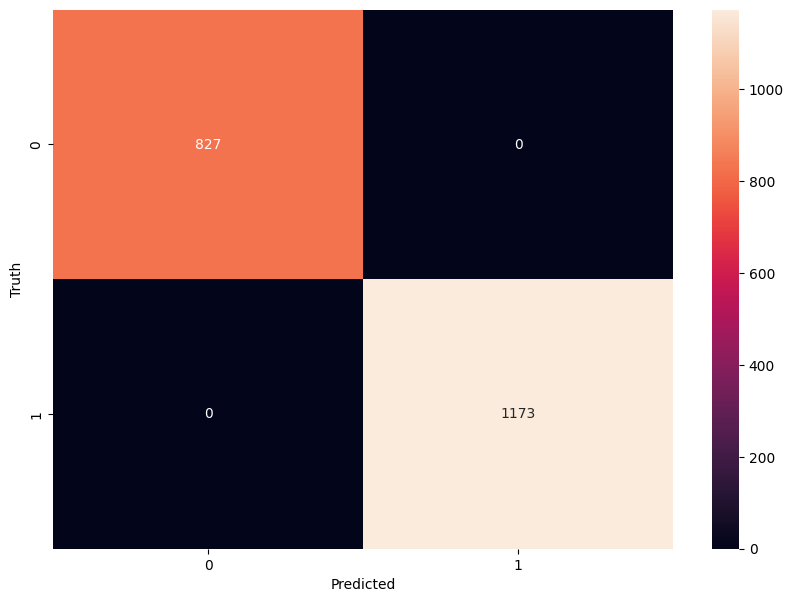

In [31]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')